## Đề bài
Dựa vào hai bảng df_loan và df_dep,
Thực hiện xây dựng báo cáo dòng tiền gồm dòng tiên vào và dòng tiền ra.
Thực hiện gom bucket kỳ hạn theo Thông tư 22/2019 của NHNN

In [ ]:
# 📘 Giải thích ý nghĩa các trường dữ liệu trong bài toán ALM

Bài toán sử dụng 2 bảng dữ liệu:

- `df_loan`  → Khoản cho vay → Dòng tiền vào  
- `df_dep`   → Khoản tiền gửi → Dòng tiền ra  

---

# 1. Bảng df_loan — Khoản cho vay (Cash Inflow)

Đây là các khoản ngân hàng cho khách vay.  
Trong tương lai khách sẽ trả lại tiền cho ngân hàng.

| Trường | Ý nghĩa | Vai trò trong ALM |
|--------|--------|-------------------|
| `loan_id` | Mã khoản vay | Nhận diện từng khoản vay |
| `customer_id` | Mã khách hàng vay | Quản lý theo khách hàng |
| `principal` | Dư nợ gốc | 💰 Số tiền gốc ngân hàng sẽ thu về |
| `interest_rate` | Lãi suất cho vay | 💵 Dùng để tính tiền lãi sẽ thu |
| `start_date` | Ngày giải ngân | Theo dõi vòng đời khoản vay |
| `maturity_date` | Ngày đáo hạn | ⏰ Xác định khi nào khách phải trả tiền |
| `days_to_maturity` | Số ngày còn lại đến đáo hạn | 📦 Dùng để xếp bucket kỳ hạn |
| `repayment_type` | Hình thức trả nợ (bullet / trả góp) | Xác định cấu trúc dòng tiền |
| `currency` | Loại tiền tệ | Quản lý rủi ro tỷ giá |

---

## Các trường quan trọng?

### 1. principal
Số tiền gốc ngân hàng sẽ thu lại khi khoản vay đáo hạn.

### 2. interest_rate
Giúp tính lãi khách hàng phải trả:

Tiền lãi ≈ Gốc × Lãi suất × Thời gian còn lại

### 3. maturity_date / days_to_maturity
Hai trường này dùng để:
- Tính số ngày còn lại
- Gom nhóm theo bucket kỳ hạn TT22

### 4. repayment_type
Ảnh hưởng cấu trúc dòng tiền:
- Bullet: trả 1 lần cuối kỳ
- Trả góp: nhiều dòng tiền nhỏ

---

# 2. Bảng df_dep — Khoản tiền gửi (Cash Outflow)

Đây là tiền khách gửi vào ngân hàng.  
Ngân hàng có nghĩa vụ phải trả lại.

| Trường | Ý nghĩa | Vai trò trong ALM |
|--------|--------|-------------------|
| `deposit_id` | Mã khoản tiền gửi | Nhận diện từng khoản |
| `customer_id` | Mã khách hàng gửi tiền | Quản lý theo khách hàng |
| `principal` | Số tiền khách gửi | 💸 Số tiền ngân hàng phải trả |
| `interest_rate` | Lãi suất tiền gửi | 💵 Dùng để tính lãi phải trả |
| `start_date` | Ngày bắt đầu gửi | Theo dõi kỳ hạn |
| `maturity_date` | Ngày đáo hạn | ⏰ Khi khách có thể rút tiền |
| `days_to_maturity` | Số ngày còn lại | 📦 Dùng để xếp bucket kỳ hạn |
| `deposit_type` | Loại tiền gửi (có kỳ hạn / không kỳ hạn) | Đánh giá độ ổn định nguồn vốn |
| `currency` | Loại tiền tệ | Quản lý rủi ro tỷ giá |

---

## Các trường quan trọng?

### 1. principal
Nghĩa vụ trả tiền gốc cho khách hàng.

### 2. interest_rate
Tính lãi ngân hàng phải trả thêm cho khách.

### 3. maturity_date / days_to_maturity
Xác định khi nào khách được rút tiền.


---

# Ứng dụng vào báo cáo dòng tiền

## Dòng tiền vào (df_loan)
Cash In = Gốc + Lãi

## Dòng tiền ra (df_dep)
Cash Out = Gốc + Lãi

## Gom nhóm theo kỳ hạn
Dựa vào:
days_to_maturity → Bucket TT22
"Ngày tiếp theo",          
"Từ ngày 2 đến ngày 7"  
"Từ ngày 8 đến ngày 30" 
"Từ ngày 31 đến ngày 180" 
"Từ ngày 181 đến 1 năm"  
"Trên 1 năm"               

## Dòng tiền ròng
Net Cash Flow = Cash In − Cash Out

In [1]:
# IMPORT THƯ VIỆN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 

# DẪN ĐƯỜNG LINK FILE
file_path = r"D:\Dataset\CF_Dataset.xlsx"

# ĐỌC FILE
df_loan = pd.read_excel(file_path, sheet_name="df_loan")
df_dep = pd.read_excel(file_path, sheet_name="df_dep")

In [5]:
#XEM DỮ LIỆU
print('==================DF_LOAN==================')
display(df_loan)
print(df_loan.info())

print('==================DF_DEP==================')
display(df_dep)
print(df_dep.info())

==================DF_LOAN==================


,loan_id,customer_id,loan_product,currency,principal,interest_rate,start_date,term_months,repricing_freq_months,repayment_type,maturity_date,next_repricing_date
0,LOAN_000001,CUST_04621,corporate,VND,120597395,0.0583,2023-09-19,60,12,principal_equal,2028-08-23,2024-09-13
1,LOAN_000002,CUST_05936,consumer,VND,156676295,0.1278,2024-10-29,36,6,annuity,2027-10-14,2025-04-27
2,LOAN_000003,CUST_01733,mortgage,VND,65629981,0.0627,2024-09-22,12,12,annuity,2025-09-17,2025-09-17
3,LOAN_000004,CUST_05344,mortgage,VND,122226222,0.0661,2023-04-09,120,1,bullet,2033-02-15,2023-05-09
4,LOAN_000005,CUST_00262,corporate,VND,170494297,0.0560,2023-08-01,24,6,principal_equal,2025-07-21,2024-01-28
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,LOAN_005996,CUST_07870,mortgage,VND,401251062,0.0952,2024-03-10,120,1,bullet,2034-01-17,2024-04-09
5996,LOAN_005997,CUST_08014,mortgage,VND,330274539,0.0528,2024-10-08,36,12,bullet,2027-09-23,2025-10-03
5997,LOAN_005998,CUST_02694,sme,VND,144712291,0.0732,2024-10-18,36,1,annuity,2027-10-03,2024-11-17
5998,LOAN_005999,CUST_05061,consumer,VND,50000000,0.1086,2023-03-18,36,1,bullet,2026-03-02,2023-04-17


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   loan_id                6000 non-null   object        
 1   customer_id            6000 non-null   object        
 2   loan_product           6000 non-null   object        
 3   currency               6000 non-null   object        
 4   principal              6000 non-null   int64         
 5   interest_rate          6000 non-null   float64       
 6   start_date             6000 non-null   datetime64[ns]
 7   term_months            6000 non-null   int64         
 8   repricing_freq_months  6000 non-null   int64         
 9   repayment_type         6000 non-null   object        
 10  maturity_date          6000 non-null   datetime64[ns]
 11  next_repricing_date    6000 non-null   datetime64[ns]
dtypes: datetime64[ns](3), float64(1), int64(3), object(5)
memory u

,deposit_id,customer_id,product_type,currency,principal,start_date,term_months,maturity_date,days_to_maturity,interest_rate
0,DEP_000001,CUST_02486,saving,VND,24055771,2025-01-23,36,2028-01-08,1102,0.061020
1,DEP_000002,CUST_05678,saving_house,VND,28355259,2023-06-01,12,2024-05-26,-220,0.053776
2,DEP_000003,CUST_09441,target_saving,VND,29280054,2025-04-10,1,2025-05-10,129,0.031118
3,DEP_000004,CUST_07173,saving_house,VND,25839378,2023-04-04,6,2023-10-01,-458,0.044513
4,DEP_000005,CUST_09459,target_saving,VND,20054690,2024-03-10,24,2026-02-28,423,0.060713
...,...,...,...,...,...,...,...,...,...,...
24995,DEP_024996,CUST_09405,term_flex,VND,5000000,2025-03-23,3,2025-06-21,171,0.038007
24996,DEP_024997,CUST_03951,term_flex,VND,16807153,2024-12-14,3,2025-03-14,72,0.036727
24997,DEP_024998,CUST_08428,term_flex,VND,5808600,2023-04-27,6,2023-10-24,-435,0.045432
24998,DEP_024999,CUST_00023,target_saving,USD,6229172,2024-03-06,24,2026-02-24,419,0.027909


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   deposit_id        25000 non-null  object        
 1   customer_id       25000 non-null  object        
 2   product_type      25000 non-null  object        
 3   currency          25000 non-null  object        
 4   principal         25000 non-null  int64         
 5   start_date        25000 non-null  datetime64[ns]
 6   term_months       25000 non-null  int64         
 7   maturity_date     25000 non-null  datetime64[ns]
 8   days_to_maturity  25000 non-null  int64         
 9   interest_rate     25000 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(3), object(4)
memory usage: 1.9+ MB
None


In [7]:
#CHỌN NGÀY BÁO CÁO
report_date = pd.to_datetime("2025-01-01")

In [11]:
#TÍNH SỐ NGÀY CÒN LẠI TỪ NGÀY BÁO CÁO ĐẾN NGÀY ĐÁO HẠN, NẾU SỐ NGÀY RA ÂM, TRẢ GIÁ TRỊ VỀ BẰNG 0 (DÙNG clip(lower=0)) 

df_loan["maturity_date"] = pd.to_datetime(df_loan["maturity_date"])
df_loan["days_to_maturity"] = (df_loan["maturity_date"] - report_date).dt.days.clip(lower=0)

df_dep["maturity_date"] = pd.to_datetime(df_dep["maturity_date"])
df_dep["days_to_maturity"] = (df_dep["maturity_date"] - report_date).dt.days.clip(lower=0)

#CHIA BUCKET THEO THÔNG TƯ 22/2019

def maturity_bucket(days):
    d = int(days)
    if d <= 1:
        return "Ngày tiếp theo"
    elif 2 <= d <= 7:
        return "Từ ngày 2 đến ngày 7"
    elif 8 <= d <= 30:
        return "Từ ngày 8 đến ngày 30"
    elif 31 <= d <= 180:
        return "Từ ngày 31 đến ngày 180"
    elif 181 <= d <= 365:
        return "Từ ngày 181 đến 1 năm"
    else:
        return "Trên 1 năm"
        
bucket_order = [
                "Ngày tiếp theo",
                "Từ ngày 2 đến ngày 7",
                "Từ ngày 8 đến ngày 30",
                "Từ ngày 31 đến ngày 180",
                "Từ ngày 181 đến 1 năm",
                "Trên 1 năm"
               ]

#GÁN BUCKET CHO DF_LOAN VÀ DF_DEP
df_loan["bucket"] = df_loan["days_to_maturity"].apply(maturity_bucket)
df_dep["bucket"] = df_dep["days_to_maturity"].apply(maturity_bucket)

#KIỂM TRA KẾT QUẢ
df_loan[["loan_id","maturity_date","days_to_maturity","bucket"]].head()
df_dep[["deposit_id","maturity_date","days_to_maturity","bucket"]].head()

,deposit_id,maturity_date,days_to_maturity,bucket
0,DEP_000001,2028-01-08,1102,Trên 1 năm
1,DEP_000002,2024-05-26,0,Ngày tiếp theo
2,DEP_000003,2025-05-10,129,Từ ngày 31 đến ngày 180
3,DEP_000004,2023-10-01,0,Ngày tiếp theo
4,DEP_000005,2026-02-28,423,Trên 1 năm


In [9]:
#TÍNH DÒNG TIỀN VÀO (SỬ DỤNG BẢNG LF_LOAN)
#công thức tính dòng tiền vào = principal + interest (trong đó Interest = Principal × Interest_rate × Days / 365)

#GỐC VÀO
df_loan["principal_inflow"] = df_loan["principal"]
#LÃI VÀO
df_loan["interest_inflow"] = df_loan["principal"] * df_loan["interest_rate"] * df_loan["days_to_maturity"] / 365
#DÒNG TIỀN VÀO (= GỐC VÀO + LÃI VÀO)
df_loan["total_inflow"] = df_loan["principal_inflow"] + df_loan["interest_inflow"]

#TỔNG HỢP DÒNG TIỀN VÀO THEO BUCKET
loan_bucket = df_loan.groupby("bucket")[["principal_inflow","interest_inflow","total_inflow"]].sum().reindex(bucket_order)

#KIỂM TRA KẾT QUẢ
print("--------------------DÒNG TIỀN VÀO--------------------")
display(loan_bucket)

--------------------DÒNG TIỀN VÀO--------------------


,principal_inflow,interest_inflow,total_inflow
bucket,,,
Ngày tiếp theo,59800044994,1.301694e+05,5.980018e+10
Từ ngày 2 đến ngày 7,4034014560,3.945999e+06,4.037961e+09
Từ ngày 8 đến ngày 30,4507748407,2.085574e+07,4.528604e+09
Từ ngày 31 đến ngày 180,45251498225,1.169699e+09,4.642120e+10
Từ ngày 181 đến 1 năm,61856932283,4.151917e+09,6.600885e+10
Trên 1 năm,516949878410,2.062601e+11,7.232100e+11


In [13]:
#TÍNH DÒNG TIỀN RA (SỬ DỤNG BẢNG LF_DEPO)
#công thức tính dòng tiền ra = principal + interest (trong đó Interest = Principal × Interest_rate × Days / 365)

#GỐC RA
df_dep["principal_outflow"] = df_dep["principal"]
#LÃI RA
df_dep["interest_outflow"] = df_dep["principal"] * df_dep["interest_rate"] * df_dep["days_to_maturity"] / 365
#DÒNG TIỀN RA (= GỐC RA + LÃI RA)
df_dep["total_outflow"] = df_dep["principal_outflow"] + df_dep["interest_outflow"]
#TỔNG HỢP DÒNG TIỀN RA THEO BUCKET
dep_bucket = df_dep.groupby("bucket")[["principal_outflow","interest_outflow","total_outflow"]].sum().reindex(bucket_order)

#KIỂM TRA KẾT QUẢ
print("--------------------DÒNG TIỀN RA--------------------")
display(dep_bucket)

--------------------DÒNG TIỀN RA--------------------


,principal_outflow,interest_outflow,total_outflow
bucket,,,
Ngày tiếp theo,420172563858,1.492150e+05,4.201727e+11
Từ ngày 2 đến ngày 7,4280262543,2.342318e+06,4.282605e+09
Từ ngày 8 đến ngày 30,19290573060,4.211448e+07,1.933269e+10
Từ ngày 31 đến ngày 180,144769562697,1.746816e+09,1.465164e+11
Từ ngày 181 đến 1 năm,116325609713,3.921511e+09,1.202471e+11
Trên 1 năm,288659725443,3.057079e+10,3.192305e+11


In [14]:
#GHÉP 2 BẢNG DÒNG TIỀN VÀO VÀ DÒNG TIỀN RA

cashflow_table = loan_bucket.merge(
                                   dep_bucket,
                                   left_index=True,
                                   right_index=True,
                                   how="outer"
                                  )
#THÊM CỘT NET CASHFLOW (NET CASHFLOW = INFLOW - OUTFLOW)
cashflow_table["net_cashflow"] = cashflow_table["total_inflow"] - cashflow_table["total_outflow"].reindex(bucket_order)

display(cashflow_table)

,principal_inflow,interest_inflow,total_inflow,principal_outflow,interest_outflow,total_outflow,net_cashflow
bucket,,,,,,,
Ngày tiếp theo,59800044994,1.301694e+05,5.980018e+10,420172563858,1.492150e+05,4.201727e+11,-3.603725e+11
Trên 1 năm,516949878410,2.062601e+11,7.232100e+11,288659725443,3.057079e+10,3.192305e+11,4.039794e+11
Từ ngày 181 đến 1 năm,61856932283,4.151917e+09,6.600885e+10,116325609713,3.921511e+09,1.202471e+11,-5.423827e+10
Từ ngày 2 đến ngày 7,4034014560,3.945999e+06,4.037961e+09,4280262543,2.342318e+06,4.282605e+09,-2.446443e+08
Từ ngày 31 đến ngày 180,45251498225,1.169699e+09,4.642120e+10,144769562697,1.746816e+09,1.465164e+11,-1.000952e+11
Từ ngày 8 đến ngày 30,4507748407,2.085574e+07,4.528604e+09,19290573060,4.211448e+07,1.933269e+10,-1.480408e+10


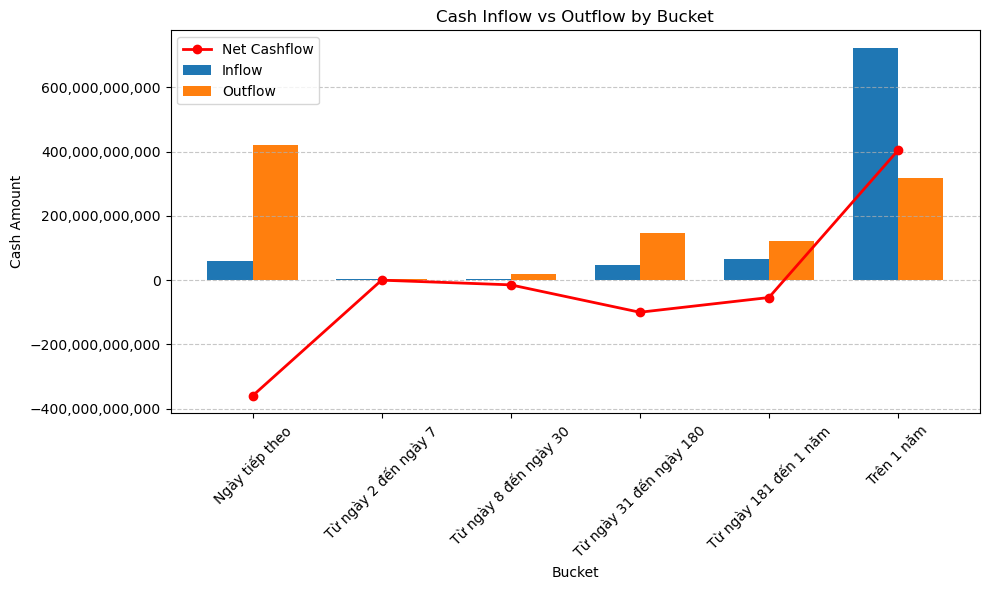

In [15]:
#VẼ BIỂU ĐỒ

cashflow_table = cashflow_table.reindex(bucket_order)
plot_data = cashflow_table.reset_index()

x = np.arange(len(plot_data["bucket"]))
width = 0.35

plt.figure(figsize=(10,6))

# Bar chart
plt.bar(x - width/2, plot_data["total_inflow"], width, label="Inflow")
plt.bar(x + width/2, plot_data["total_outflow"], width, label="Outflow")

# Line chart cho Net Cashflow
plt.plot(x, plot_data["net_cashflow"], marker="o", linewidth=2, color="red", label="Net Cashflow")

# Trục
plt.xticks(x, plot_data["bucket"], rotation=45)
plt.xlabel("Bucket")
plt.ylabel("Cash Amount")
plt.title("Cash Inflow vs Outflow by Bucket")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Format tiền có dấu phẩy
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()

plt.show()